In [17]:
%matplotlib widget

In [18]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [19]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Mrk-789_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Mrk-789_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     379   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        60   (2094, 964)   float32   


In [20]:
image_cut = image[75:175, 0:1890]
image_error_cut = image_error[75:175, 0:1890]

In [21]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Text(0.5, 91.56249999999999, 'wavelenght')

In [22]:
z = 0.03144 
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

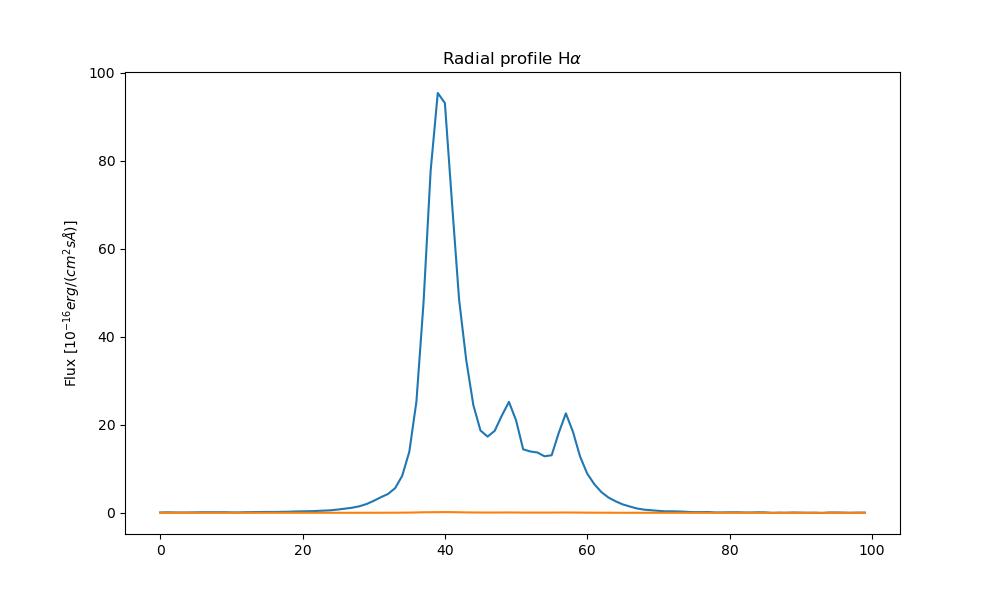

In [23]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

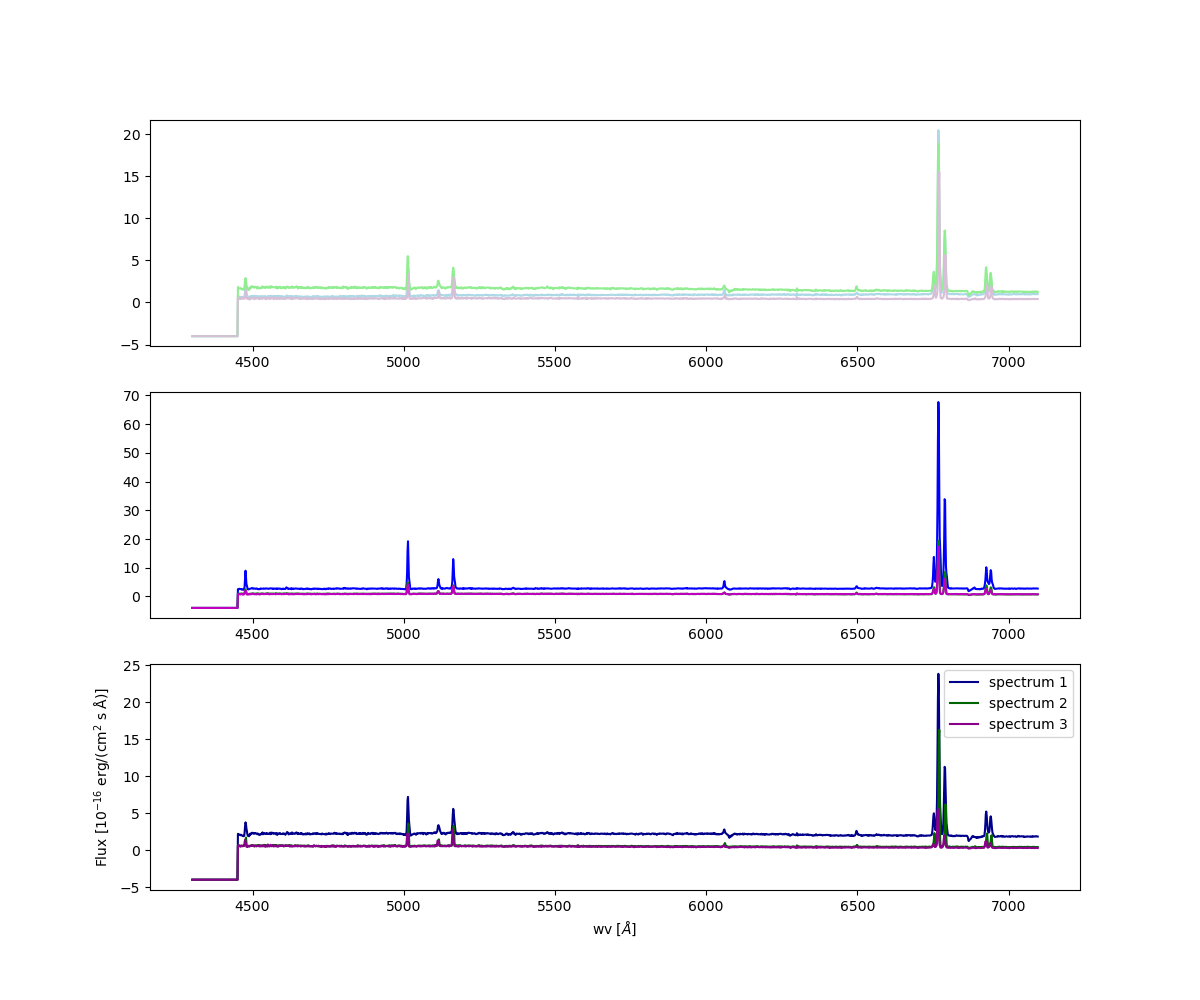

In [24]:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Fit/Halpha_fit.csv", index_col=0)
os.makedirs('4pix_center', exist_ok=True)

peaks = fit_HA.iloc[3].values

fig, ax = plt.subplots(3, 1, figsize=(12, 10))
spectra_sx =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_c =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_dx =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_sx = np.zeros((len(peaks), image_error_cut.shape[1]))
spectra_err_c = np.zeros((len(peaks), image_error_cut.shape[1]))
spectra_err_dx = np.zeros((len(peaks), image_error_cut.shape[1]))
data_sx = []
data_c = []
data_dx = []
colors_sx =  ['lightblue', 'lightgreen', 'thistle']
colors_c = ['blue', 'green', 'm']
colors_dx = ['darkblue', 'darkgreen', 'darkmagenta']

#Cut one sigma 
for i in range(len(peaks)):
    mask_sx = (x_axes > (peaks[i]-2)-4)*(x_axes < peaks[i]-2)
    mask_c = (x_axes > peaks[i]-2)*(x_axes < peaks[i]+2)
    mask_dx = (x_axes > peaks[i]+2)*(x_axes < (peaks[i]+2)+4)
    spectra_sx[i] = np.sum(image_cut[mask_sx, :], axis = 0)
    spectra_c[i] = np.sum(image_cut[mask_c, :], axis = 0)
    spectra_dx[i] = np.sum(image_cut[mask_dx, :], axis = 0)
    spectra_err_sx[i] = np.sqrt(np.sum(image_error_cut[mask_sx, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    spectra_err_c[i] = np.sqrt(np.sum(image_error_cut[mask_c, :]**2, axis = 0))
    spectra_err_dx[i] = np.sqrt(np.sum(image_error_cut[mask_dx, :]**2, axis = 0))
    ax[0].plot(wv, spectra_sx[i], color = colors_sx[i], label = f'spectrum {i+1}')
    ax[1].plot(wv, spectra_c[i], color = colors_c[i], label = f'spectrum {i+1}')
    ax[2].plot(wv, spectra_dx[i], color = colors_dx[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table_sx = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_sx[i].reshape(-1, 1), spectra_err_sx[i].reshape(-1, 1)), axis=1)
    spectrum_table_c = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_c[i].reshape(-1, 1), spectra_err_c[i].reshape(-1, 1)), axis=1)
    spectrum_table_dx = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_dx[i].reshape(-1, 1), spectra_err_dx[i].reshape(-1, 1)), axis=1)
    data_sx.append(spectrum_table_sx)
    data_c.append(spectrum_table_c)
    data_dx.append(spectrum_table_dx)
    
np.savetxt(os.path.join('4pix_center', 'Spectrum_sx_1.txt'), data_sx[0])
np.savetxt(os.path.join('4pix_center', 'Spectrum_sx_2.txt'), data_sx[1])
np.savetxt(os.path.join('4pix_center', 'Spectrum_sx_3.txt'), data_sx[2])

np.savetxt(os.path.join('4pix_center', 'Spectrum_center_1.txt'), data_c[0])
np.savetxt(os.path.join('4pix_center', 'Spectrum_center_2.txt'), data_c[1])
np.savetxt(os.path.join('4pix_center', 'Spectrum_center_3.txt'), data_c[2])

np.savetxt(os.path.join('4pix_center', 'Spectrum_dx_1.txt'), data_dx[0])
np.savetxt(os.path.join('4pix_center', 'Spectrum_dx_2.txt'), data_dx[1])
np.savetxt(os.path.join('4pix_center', 'Spectrum_dx_3.txt'), data_dx[2])

## S/N continuum
Fare segnale/rumore per ogni pixel e poi fai la media, questo per le tre regioni

In [25]:
import pandas as pd

mask_continuum_1 = (wv > 4600)*(wv < 4900)
mask_continuum_2 = (wv > 5300)*(wv < 5800)
mask_continuum_3 = (wv > 6100)*(wv < 6600)

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_sx[i, mask_continuum_1]/spectra_err_sx[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_sx[i, mask_continuum_2]/spectra_err_sx[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_sx[i, mask_continuum_3]/spectra_err_sx[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(len(peaks))],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('4pix_center', 'SNR_sx_continuum.csv')
df.to_csv(df_path, float_format='%.3f')

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_c[i, mask_continuum_1]/spectra_err_c[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_c[i, mask_continuum_2]/spectra_err_c[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_c[i, mask_continuum_3]/spectra_err_c[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(len(peaks))],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('4pix_center', 'SNR_c_continuum.csv')
df.to_csv(df_path, float_format='%.3f')

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_dx[i, mask_continuum_1]/spectra_err_dx[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_dx[i, mask_continuum_2]/spectra_err_dx[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_dx[i, mask_continuum_3]/spectra_err_dx[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(len(peaks))],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('4pix_center', 'SNR_c_continuum.csv')
df.to_csv(df_path, float_format='%.3f')

                Spettro_1  Spettro_2  Spettro_3
Continuum_1     17.084996  35.822094  12.028032
Continuum_2     28.172385  45.236459  17.443068
Continuum_3     34.625200  47.251423  19.232916
Mean_Continuum  26.627527  42.769992  16.234672
                Spettro_1  Spettro_2  Spettro_3
Continuum_1     48.572167  21.789031  19.902972
Continuum_2     62.387508  28.545481  28.513386
Continuum_3     70.441566  31.059675  32.765178
Mean_Continuum  60.467080  27.131396  27.060512
                Spettro_1  Spettro_2  Spettro_3
Continuum_1     42.342662  14.050788  13.381320
Continuum_2     54.400241  19.190644  17.332962
Continuum_3     59.094014  20.363434  16.977640
Mean_Continuum  51.945639  17.868289  15.897307


## S/N emission lines 

In [26]:
def SNR_line(wv, wv_line, spectra, peaks):
    left_region = (wv > wv_line-25)*(wv < wv_line-10) 
    right_region = (wv > wv_line+10)*(wv < wv_line+25) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise 

def SNR_SII_line(wv, wv_line, spectra, peaks):
    left_region = (wv > 6916-15)*(wv < 6916) 
    right_region = (wv > 6953)*(wv < 6953+15) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise 

def SNR_HA_NII(wv, wv_line, spectra, peaks):
    left_region = (wv > 6725) & (wv < 6740)
    right_region = (wv > 6800) & (wv < 6815)
    clean_mask = left_region | right_region #But also for the two NII lines bc they are closed

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))

    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 

In [27]:
index = ['Component_1', 'Component_2', 'Component_3']
SNR_HB_1, signal_HB_1, noise_HB_1 = SNR_line(wv, l_HB, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_HB_1).reshape(-1, 1),
    np.array(signal_HB_1).reshape(-1, 1),
    np.array(noise_HB_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index )
df_path = os.path.join('4pix_center', 'SNR_HB_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_2, signal_HB_2, noise_HB_2 = SNR_line(wv, l_HB, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_HB_2).reshape(-1, 1),
    np.array(signal_HB_2).reshape(-1, 1),
    np.array(noise_HB_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_HB_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_3, signal_HB_3, noise_HB_3 = SNR_line(wv, l_HB, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_HB_3).reshape(-1, 1),
    np.array(signal_HB_3).reshape(-1, 1),
    np.array(noise_HB_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_HB_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_1, signal_SII_1, noise_SII_1 = SNR_SII_line(wv, l_SII_1, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_SII_1).reshape(-1, 1),
    np.array(signal_SII_1).reshape(-1, 1),
    np.array(noise_SII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_SII_1_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2, signal_SII_2, noise_SII_2 = SNR_SII_line(wv, l_SII_1, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_SII_2).reshape(-1, 1),
    np.array(signal_SII_2).reshape(-1, 1),
    np.array(noise_SII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_SII_1_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_3, signal_SII_3, noise_SII_3 = SNR_SII_line(wv, l_SII_1, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_SII_3).reshape(-1, 1),
    np.array(signal_SII_3).reshape(-1, 1),
    np.array(noise_SII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_SII_1_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_1, signal_SII_2_1, noise_SII_2_1 = SNR_SII_line(wv, l_SII_2, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_1).reshape(-1, 1),
    np.array(signal_SII_2_1).reshape(-1, 1),
    np.array(noise_SII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_SII_2_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_2, signal_SII_2_2, noise_SII_2_2 = SNR_SII_line(wv, l_SII_2, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_2).reshape(-1, 1),
    np.array(signal_SII_2_2).reshape(-1, 1),
    np.array(noise_SII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_SII_2_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_3, signal_SII_2_3, noise_SII_2_3 = SNR_SII_line(wv, l_SII_2, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_3).reshape(-1, 1),
    np.array(signal_SII_2_3).reshape(-1, 1),
    np.array(noise_SII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_SII_2_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_1, signal_OIII_1, noise_OIII_1 = SNR_line(wv, l_OIII_1, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_OIII_1).reshape(-1, 1),
    np.array(signal_OIII_1).reshape(-1, 1),
    np.array(noise_OIII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_OIII_1_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2, signal_OIII_2, noise_OIII_2 = SNR_line(wv, l_OIII_1, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2).reshape(-1, 1),
    np.array(signal_OIII_2).reshape(-1, 1),
    np.array(noise_OIII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_OIII_1_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_3, signal_OIII_3, noise_OIII_3 = SNR_line(wv, l_OIII_1, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_OIII_3).reshape(-1, 1),
    np.array(signal_OIII_3).reshape(-1, 1),
    np.array(noise_OIII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_OIII_1_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_1, signal_OIII_2_1, noise_OIII_2_1 = SNR_line(wv, l_OIII_2, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_1).reshape(-1, 1),
    np.array(signal_OIII_2_1).reshape(-1, 1),
    np.array(noise_OIII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_OIII_2_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_2, signal_OIII_2_2, noise_OIII_2_2 = SNR_line(wv, l_OIII_2, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_2).reshape(-1, 1),
    np.array(signal_OIII_2_2).reshape(-1, 1),
    np.array(noise_OIII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_OIII_2_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_3, signal_OIII_2_3, noise_OIII_2_3 = SNR_line(wv, l_OIII_2, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_3).reshape(-1, 1),
    np.array(signal_OIII_2_3).reshape(-1, 1),
    np.array(noise_OIII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_OIII_2_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_1, signal_HA_1, noise_HA_1 = SNR_HA_NII(wv, l_HA, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_HA_1).reshape(-1, 1),
    np.array(signal_HA_1).reshape(-1, 1),
    np.array(noise_HA_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_HA_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_2, signal_HA_2, noise_HA_2 = SNR_HA_NII(wv, l_HA, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_HA_2).reshape(-1, 1),
    np.array(signal_HA_2).reshape(-1, 1),
    np.array(noise_HA_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_HA_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_3, signal_HA_3, noise_HA_3 = SNR_HA_NII(wv, l_HA, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_HA_3).reshape(-1, 1),
    np.array(signal_HA_3).reshape(-1, 1),
    np.array(noise_HA_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_HA_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_1, signal_NII_1, noise_NII_1 = SNR_HA_NII(wv, l_NII_1, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_NII_1).reshape(-1, 1),
    np.array(signal_NII_1).reshape(-1, 1),
    np.array(noise_NII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_NII_1_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2, signal_NII_2, noise_NII_2 = SNR_HA_NII(wv, l_NII_1, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_NII_2).reshape(-1, 1),
    np.array(signal_NII_2).reshape(-1, 1),
    np.array(noise_NII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_NII_1_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_3, signal_NII_3, noise_NII_3 = SNR_HA_NII(wv, l_NII_1, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_NII_3).reshape(-1, 1),
    np.array(signal_NII_3).reshape(-1, 1),
    np.array(noise_NII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_NII_1_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_1, signal_NII_2_1, noise_NII_2_1 = SNR_HA_NII(wv, l_NII_2, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_1).reshape(-1, 1),
    np.array(signal_NII_2_1).reshape(-1, 1),
    np.array(noise_NII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_NII_2_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_2, signal_NII_2_2, noise_NII_2_2 = SNR_HA_NII(wv, l_NII_2, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_2).reshape(-1, 1),
    np.array(signal_NII_2_2).reshape(-1, 1),
    np.array(noise_NII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_NII_2_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_3, signal_NII_2_3, noise_NII_2_3 = SNR_HA_NII(wv, l_NII_2, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_3).reshape(-1, 1),
    np.array(signal_NII_2_3).reshape(-1, 1),
    np.array(noise_NII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('4pix_center', 'SNR_NII_2_dx.csv')
df.to_csv(df_path, float_format='%.3f')